### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_style("darkgrid")
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
from astropy.constants import c, k_B, R_earth
import src.read_database as read_database
import src.map_properties as map_properties
import src.satellite_properties as satellite_properties
import src.store_FOV_indices as store_FOV_indices
import src.Friis as Friis
import src.power_3D_cube as power_3D_cube
import time
%matplotlib inline   

In [2]:
start_time=time.time()

#### Schematic representation of the architecture

![image](./rfi_framework.png)

### Read FM Transmitter Database 

In [3]:
n = str(input("Enter the number of countries to include"))

Enter the number of countries to includeAll


In [4]:
df = read_database.read_FM_database(countries=read_database.get_countries(n))

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)


### Define frequency range  

In [5]:
freq_range = read_database.get_freq_range()

Please enter the minimum value of the frequency range (in MHz): 55
Please enter the maximum value of the frequency range (in MHz): 110
Please enter the resolution of the frequency (in MHz): 0.244


In [6]:
df = read_database.extract_common_freq(df, freq_range)


### Define resolution of the Healpy map

In [7]:
print('----------- Resolution of the map -----------')

# The default value of nside is 16
nside = int(input("Enter the NSIDE of the healpy map"))
npix, pix_array, phi, theta = map_properties.get_map(nside)

print(f"The number of pixels for the given NSIDE: {(hp.nside2npix(nside))}")
print(f"Approximate resolution in degrees for given nside {np.degrees(hp.nside2resol(nside)):.2f}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.2f} square degrees")

----------- Resolution of the map -----------
Enter the NSIDE of the healpy map32
The number of pixels for the given NSIDE: 12288
Approximate resolution in degrees for given nside 1.83
Pixel area: 3.36 square degrees


In [8]:
beam_pattern=str(input('Enter desired beam pattern:'))

Enter desired beam pattern:cos square


### Allocate pixel number to the Latitude and Longitude of each FM transmitter in the database

In [9]:
df, pixel_indices = read_database.allocate_pixel_num(nside, df)


### Define altitude of the satellite orbit 

In [10]:
altitudes = satellite_properties.get_altitudes() #input format: alt1 alt2 alt3 (example:650 705 36000)

Enter desired altitudes:650 705 35900


### Calculation of Elevation angle

In [11]:
elev_angle = satellite_properties.calc_elev_angle(npix, phi, theta, altitudes)

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/satellite_properties.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  elev_ang[k, i, j] = -(np.degrees(np.arctan((B - cos_theta_j) / sin_y_ang)))
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/satellite_properties.py:41: RuntimeWarning: invalid value encountered in arccos
  y_ang = np.arccos(x_ang)


### Define radiation pattern of the satellite antenna beam [optional]

In [12]:
np.shape(elev_angle)

(3, 12288, 12288)

In [13]:
beam = satellite_properties.get_beam_pattern("sin square", theta)
az = 0 # Assuming the satellite antenna beam to be symmetric across azimuth

###  Calculation of Field of view (FOV) and Radius of the FOV of the satellite

In [14]:
FOV = satellite_properties.calc_field_of_view(altitudes)

The Field of view of the satellite at a height of 650.00 km is 2.27 radians
The Field of view of the satellite at a height of 705.00 km is 2.24 radians
The Field of view of the satellite at a height of 35900.00 km is 0.30 radians


In [15]:
Central_angle, Rad_of_FOV = satellite_properties.calc_central_angle(altitudes)

The Radius of the Field of View for a height of 650.00 km in radians is 0.43
The Radius of the Field of View for a height of 705.00 km in radians is 0.45
The Radius of the Field of View for a height of 35900.00 km in radians is 1.42


# Create power cube 

In [16]:
disc = store_FOV_indices.get_disc(nside, phi, theta, Rad_of_FOV, pix_array)

In [17]:
pix_common = store_FOV_indices.get_common_pix(pix_array, Rad_of_FOV, disc, df)

In [18]:
found_common = store_FOV_indices.get_common_Tx(pixel_indices, pix_common, Rad_of_FOV)

In [19]:
Rx_Power_in_Kelvin = Friis.calc_Friis(df, altitudes)[2]
# print(df)

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/Friis.py:30: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBm[j][i]= 10.*np.log10( Rx_Power[j][i])+30
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/Friis.py:32: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBW[j][i]= 10.*np.log10( Rx_Power[j][i])


In [20]:
df_fov = power_3D_cube.get_dataframe_fov(Rx_Power_in_Kelvin, df, found_common, Rad_of_FOV, elev_angle,beam_pattern)

In [21]:
power_output = power_3D_cube.get_power_output(npix, Rad_of_FOV, freq_range, df_fov)

In [22]:
end_time=time.time()

In [23]:
execution_time = end_time - start_time

print(f"Execution time: {execution_time/60} minutes")

Execution time: 119.36608612934748 minutes


## Plot  Spectrum 

<b> The first index represents altitude of the satellite <b>\
<b> The second index represents location of the satellite(pixel number) <b>\
<b> The third index represents range of frequencies <b>

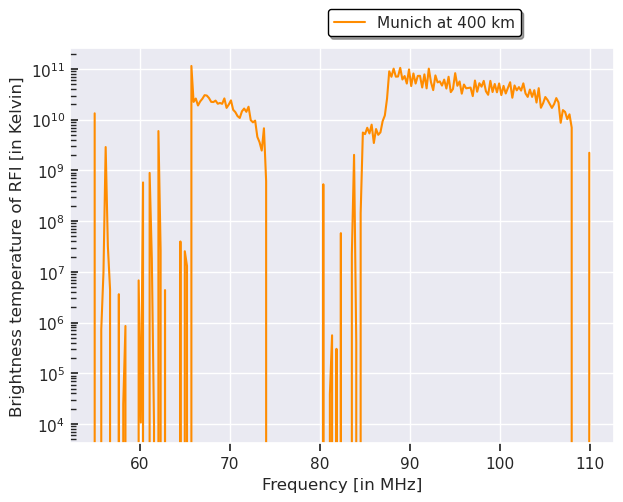

In [24]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
munpix=hp.ang2pix(nside, 11.580224258292716,48.13469781361046,lonlat=True)
plt.plot(freq_range,power_output[0,munpix,:], label='Munich at 400 km', color='darkorange') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)
# plt.savefig("/home/sonia/Documents/RFI_PAPER/Munich_36000_new.pdf")

In [25]:
altitudes[0]

650.0

# Orbit evaluation

In [26]:
import pytz
from datetime import datetime
from dateutil.relativedelta import relativedelta
from skyfield.api import load, wgs84, EarthSatellite

In [89]:
# Predefine constants
deltaT=8.640869140625
thresholdFOM=54 # threshold FOM for radio quiet zones
tot_band=freq_range[-1]-freq_range[0]

## RFI assessment in polar orbit

In [90]:
# open TLE archive data
file=open('../TLE_files/landsat_archive') # this file contains multiple TLEs everyday for mulitple years
content=file.read()
ts = load.timescale()
eph=load('de421.bsp') # solar system ephemeris to obtain 'sunlit' parameter. (used later)

### Slice one year of TLEs

In [91]:
lineone=[]
linetwo=[]
num=2000
days=np.zeros((num))
for i in range(2000):
    line11=(content[((2*i)*70):((2*i)*70)+69]) # first line of all TLEs
    line22=(content[((2*i+1)*70):((2*i+1)*70)+69]) # second line of all TLEs
    sate=EarthSatellite(line11,line22,'Landsat7',ts) # call EarthSatellite function (skyfield library) 
                                                     # To access TLE epochs in normal date time format.
#     print(sate)
    lineone.append(line11)
    linetwo.append(line22)
    year=sate.epoch.utc.year
    month=sate.epoch.utc.month
    day=sate.epoch.utc.day
    days[i]+=day
    if year==2000.0:
        if month==4.0:
            if day==15.0:
                   break # Stop after appending one year's worth of TLEs 
                         # Each day still contains multiple TLEs (just one per day is required.)
                         # Next cell gets one TLE per day.
    
    
    

### Get one TLE per day for one year

In [92]:
uniq_idx=[]
for i in range(len(lineone)):
    if i>0:
        if days[i]!=days[i-1]:
            uniq_idx.append(i) # obtained indices such that there's one TLE per day
        
   

## Propagate orbit for one year

In [93]:
subpoints=[] # This will contain ground track coordinates
sunlit=[] # Boolean array of satellite is sunlit or not
t11=[] 
for idx,i in enumerate(uniq_idx):
    if idx==0:
        line1=lineone[i] # first line of TLE on day 1 of OP
        line2=linetwo[i] # second line
        satellite = EarthSatellite(line1, line2, 'Landsat-7', ts) # call EarthSatellite function to do OP
        tz = pytz.timezone('UTC') # define a standard timezone (UTC in this case)
        st=satellite.epoch.utc # starting point of OP is the epoch of the TLE for day 1 of OP
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second))) 
        t0 = ts.utc(dt)  # starting point of OP                                                             
        t1 = ts.utc(dt + relativedelta(hours=24)) # end point of OP (1 day propagation)
        t11.append(t1) # record the end point of OP of that day. Use this as starting point for next day's OP.
        timescales = ts.linspace(t0,t1, 10000) # define a time linspace (skyfield lib function) with time
        # resolution of 10000 points. (10000 points in 24 hours) 

        geocentrics = satellite.at(timescales) # Note geocentrics (state vectors with geocentric reference frame) at each point (10000 points)
        sunlit.append(geocentrics.is_sunlit(eph)) # record sunlit Boolean
        subpoints.append(wgs84.subpoint_of(geocentrics)) # convert state vectors to wgs84 (lat,lon) to get ground trace.
    else: # for days after day 0:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-7', ts)
        tz = pytz.timezone('UTC')
        st=t11[idx-1].utc # we use the end point of previous day's OP as starting point here.
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))

    

### Save all params of one year orbit

In [94]:
# ground trace (subpoints list) isn't in lat lon format yet. This cell does that.
year_lon=[]
year_lat=[]
for i in range(len(subpoints)):
    year_lon.append(subpoints[i].longitude.degrees)
    year_lat.append(subpoints[i].latitude.degrees)

In [95]:
sunlit=np.array(sunlit)
year_lon=np.array(year_lon)
year_lat=np.array(year_lat)
# now year_lat and year_lon have shape of 365,10000. This means there are 10000 ground track coords per day.

### FOM map for landsat (alt: 705 km)

In [96]:
# this cell calculates FOM of each pixel over an altitude of 705 km
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[1,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

### South Atlantic anomaly

In [97]:
saalon=np.linspace(-90,40,100)
saalat=np.linspace(-50,0,100)
blon,blat=np.meshgrid(saalon,saalat)
bpix=hp.ang2pix(nside,blon,blat,lonlat=True)

In [98]:
FOM_map[bpix]=0 # Set SAA pixels to 0 FOM

In [99]:
FOMtime1=np.zeros(55) # define FOM bins of width 1 MHz 
for i in range(len(year_lat)): # i is a day of OP
    for j in range(len(year_lat[0])): # j is each ground track coord of that sliced day. (10000 points)
        orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True) # get pixel of coord
        fomval=int(FOM_map[orbpix]) # obtain FOM value in integer format
        if sunlit[i,j]==True: 
            FOMtime1[fomval]+=0 # Does not count the FOM if it is sunlit.
        else:
            FOMtime1[fomval]+=deltaT # Adds deltaT if the point is not sunlit, as it spends deltaT time at that
                                     # point.

In [100]:
np.sum(FOMtime1)/3600

2964.05813937717

In [101]:
(FOMtime1[-1])/3600 # Total time spent in highest FOM bin per year in hours

234.18435540093316

### Max uninterrupted RFI free time per day

In [102]:
# This cell calculates maximum amount of uninterrupted >54 FOM time per day.
# in this case there is a max of 35.5 mins. (note that this is the max per day.)

In [103]:
dailymax=[]
dailytotal=[]
for h in range(year_lat.shape[0]):
    oneslice=sunlit[h,:]
    count=0
    foms=[]
    for k in range(len(oneslice)):
        if oneslice[k-1]==oneslice[k]==False:
            pix=hp.ang2pix(nside,year_lon[h,k],year_lat[h,k],lonlat=True)
            foms.append(int(FOM_map[pix]))
            valz=[]
            for i in range(len(foms)-1):
                if foms[i+1]==foms[i]>=thresholdFOM:
                    count+=1
                else:
                    valz.append(count*(deltaT/60))
                    count=0
    dailymax.append(max(valz)) 
    dailytotal.append(sum(valz))



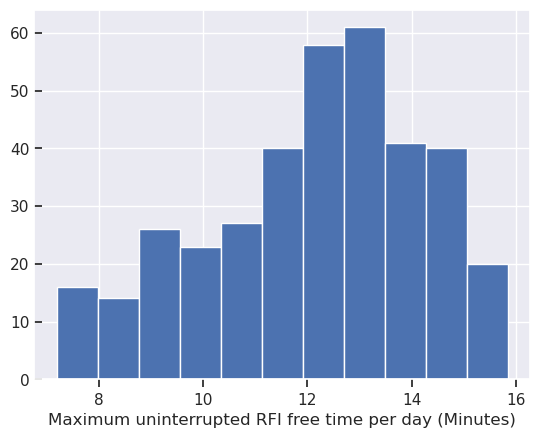

In [104]:
from src2.FDrule import FDrule
plt.hist(dailymax,bins=FDrule(dailymax))
plt.xlabel('Maximum uninterrupted RFI free time per day (Minutes)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/polar_unint2.pdf',dpi=600,bbox_inches='tight')
plt.show()

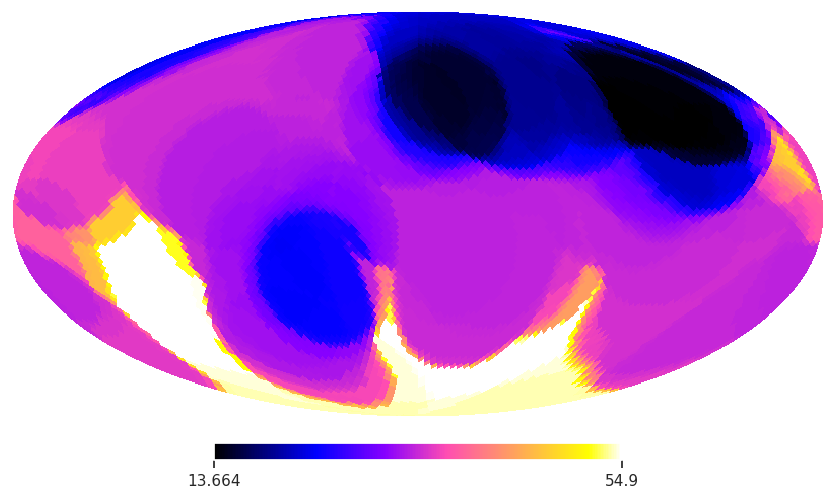

In [110]:
# this cell calculates FOM of each pixel over an altitude of 705 km
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[1,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band


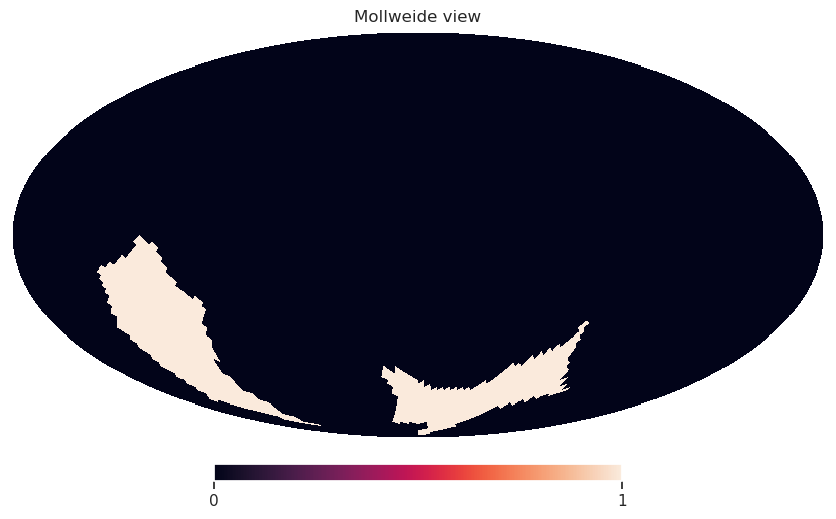

In [43]:
goodpix=np.where(FOM_map>54)
newfom=np.zeros(hp.nside2npix(nside))
newfom[goodpix]+=1
hp.mollview(newfom,flip='geo')

In [112]:
thresholdFOM

54

### RFI lines over good regions

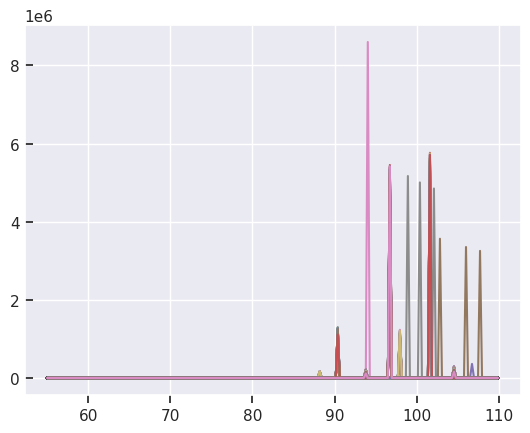

In [44]:
goodpix=np.array(goodpix)[0]

for i in goodpix:
    lines=power_output[1,i,:]
    plt.plot(freq_range,lines)
plt.show()

## RFI assessment in equatorial orbit

### FOM map for AstroSAT (alt: 650km)

In [115]:
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[0,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

In [116]:
saalon=np.linspace(-90,40,100)
saalat=np.linspace(-50,0,100)
blon,blat=np.meshgrid(saalon,saalat)
bpix=hp.ang2pix(nside,blon,blat,lonlat=True)
FOM_map[bpix]=0

In [117]:
# open TLE archive
file=open('../TLE_files/sat000040930.txt') #Astrosat data
content=file.read()
ts = load.timescale()
eph=load('de421.bsp')

In [118]:
lineone=[]
linetwo=[]
num=478
days=[]
for i in range(479):
    line11=(content[((2*i)*70):((2*i)*70)+69])
    line22=(content[((2*i+1)*70):((2*i+1)*70)+69])
    sate=EarthSatellite(line11,line22,'Landsat7',ts)
#     print(sate)
    lineone.append(line11)
    linetwo.append(line22)
    year=sate.epoch.utc.year
    month=sate.epoch.utc.month
    day=sate.epoch.utc.day
    days.append(day)
    if year==2014.0:
        if month==1.0:
            if day==1.0:
                   break
    
    
uniq_idx=[]
for i in range(len(lineone)):
    if i>0:
        if days[i]!=days[i-1]:
            uniq_idx.append(i)
        
     

In [119]:
len(days)

479

In [120]:
# in the case of equatorial orbits, TLEs are not renewed as often since they don't perturb as much as 
# polar orbits. Hence there are TLEs every day with certain cases where there is one TLE for 2 days and so on.
# reps array records the gaps in TLE epochs. (if there is a 2 in reps, that means there is one TLE for two days.)

In [121]:
reps=[1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 3., 2., 2., 1., 2., 4., 1., 1., 2., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       1., 1., 2., 2., 1., 1., 1., 1., 1., 1., 2., 1., 4., 1., 1., 1., 2.,
       3., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 2., 1., 1., 1.,
       1., 1., 1., 2., 1., 1., 1., 1., 2., 1., 1., 1., 2., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 2.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1.,
       1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 3., 1., 1., 3., 1., 1.,
       2., 1., 1., 1.,1.]

In [122]:
reps=np.array(reps)

In [123]:
subpoints=[]
sunlit=[]
t11=[]
for idx,i in enumerate(uniq_idx):
    if idx==0:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'AstroSat', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=satellite.epoch.utc
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))
    else:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'AstroSat', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=t11[idx-1].utc
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24*reps[idx])) # multiply 24 hrs with reps to account for skips.
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))

    

AstroSat catalog #40930 epoch 2016-01-02 02:33:11 UTC
AstroSat catalog #40930 epoch 2016-01-03 23:57:14 UTC
AstroSat catalog #40930 epoch 2016-01-05 11:37:34 UTC
AstroSat catalog #40930 epoch 2016-01-06 02:13:10 UTC
AstroSat catalog #40930 epoch 2016-01-07 02:32:29 UTC
AstroSat catalog #40930 epoch 2016-01-08 09:20:57 UTC
AstroSat catalog #40930 epoch 2016-01-09 08:02:59 UTC
AstroSat catalog #40930 epoch 2016-01-10 01:53:08 UTC
AstroSat catalog #40930 epoch 2016-01-11 03:49:45 UTC
AstroSat catalog #40930 epoch 2016-01-12 02:31:47 UTC
AstroSat catalog #40930 epoch 2016-01-13 07:42:58 UTC
AstroSat catalog #40930 epoch 2016-01-14 06:24:59 UTC
AstroSat catalog #40930 epoch 2016-01-15 08:21:35 UTC
AstroSat catalog #40930 epoch 2016-01-16 03:49:01 UTC
AstroSat catalog #40930 epoch 2016-01-17 04:08:19 UTC
AstroSat catalog #40930 epoch 2016-01-18 07:42:11 UTC
AstroSat catalog #40930 epoch 2016-01-19 04:46:55 UTC
AstroSat catalog #40930 epoch 2016-01-20 01:51:38 UTC
AstroSat catalog #40930 epoc

AstroSat catalog #40930 epoch 2016-06-16 04:20:38 UTC
AstroSat catalog #40930 epoch 2016-06-17 01:25:34 UTC
AstroSat catalog #40930 epoch 2016-06-18 03:22:24 UTC
AstroSat catalog #40930 epoch 2016-06-19 03:41:57 UTC
AstroSat catalog #40930 epoch 2016-06-20 02:24:11 UTC
AstroSat catalog #40930 epoch 2016-06-21 04:21:01 UTC
AstroSat catalog #40930 epoch 2016-06-22 19:16:16 UTC
AstroSat catalog #40930 epoch 2016-06-23 01:45:29 UTC
AstroSat catalog #40930 epoch 2016-06-24 03:42:19 UTC
AstroSat catalog #40930 epoch 2016-06-25 04:01:51 UTC
AstroSat catalog #40930 epoch 2016-06-26 01:06:47 UTC
AstroSat catalog #40930 epoch 2016-06-27 01:26:19 UTC
AstroSat catalog #40930 epoch 2016-06-28 00:08:34 UTC
AstroSat catalog #40930 epoch 2016-06-29 02:05:24 UTC
AstroSat catalog #40930 epoch 2016-06-30 00:47:38 UTC
AstroSat catalog #40930 epoch 2016-07-01 10:51:00 UTC
AstroSat catalog #40930 epoch 2016-07-02 03:04:02 UTC
AstroSat catalog #40930 epoch 2016-07-03 00:08:58 UTC
AstroSat catalog #40930 epoc

In [124]:
year_lon=[]
year_lat=[]
for i in range(len(subpoints)):
    year_lon.append(subpoints[i].longitude.degrees)
    year_lat.append(subpoints[i].latitude.degrees)

In [125]:
sunlit=np.array(sunlit)

In [126]:
year_lon=np.array(year_lon)
year_lat=np.array(year_lat)

In [127]:
FOMtime=np.zeros(55)
for i in range(len(year_lat)):
    for j in range(len(year_lat[0])):
        orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
        fomval=int(FOM_map[orbpix])
        if sunlit[i,j]==True:
            FOMtime[fomval]+=0
        else:
            FOMtime[fomval]+=deltaT

In [128]:
fomvals=np.linspace(0,55,55)

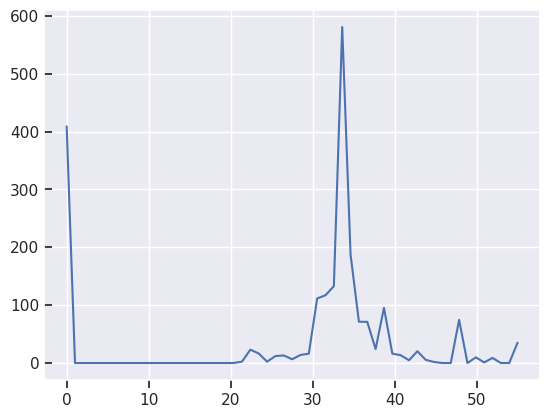

In [129]:
plt.plot(fomvals,(FOMtime/3600))
plt.show()

In [130]:
FOMtime1[-1]/3600

234.18435540093316

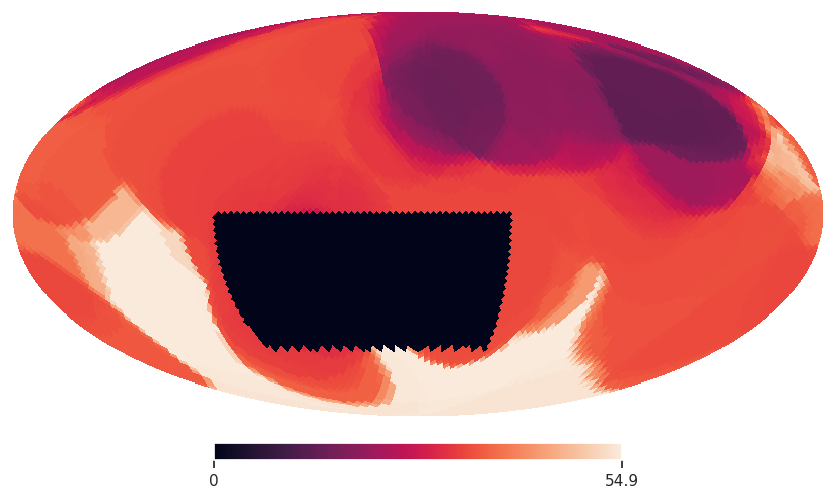

In [131]:
hp.mollview(FOM_map,flip='geo',title='')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/saaFOM.pdf')

In [132]:
dailymax=[]
dailytotal=[]
for h in range(year_lat.shape[0]):
    oneslice=sunlit[h,:]
    count=0
    foms=[]
    for k in range(len(oneslice)):
        if oneslice[k-1]==oneslice[k]==False:
            pix=hp.ang2pix(nside,year_lon[h,k],year_lat[h,k],lonlat=True)
            foms.append(int(FOM_map[pix]))
            valz=[]
            for i in range(len(foms)-1):
                if foms[i+1]==foms[i]>=thresholdFOM:
                    count+=1
                else:
                    valz.append(count*(deltaT/60))
                    count=0
    dailymax.append(max(valz))            
    dailytotal.append(sum(valz))


In [133]:
(np.mean(dailymax)*365)/60

16.963926722381657

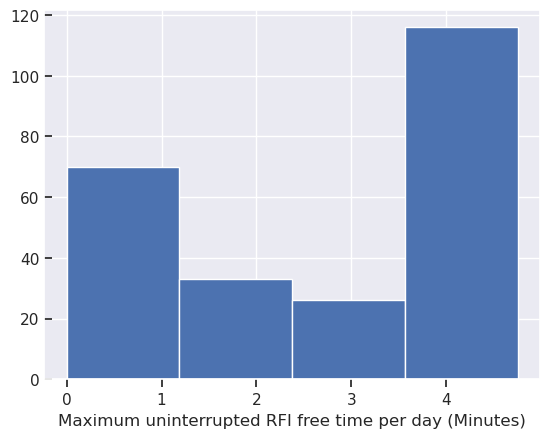

In [134]:
plt.hist(dailymax,bins=FDrule(dailymax))
plt.xlabel('Maximum uninterrupted RFI free time per day (Minutes)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/equi_unint2.pdf',dpi=600,bbox_inches='tight')

plt.show()

In [65]:
OWFOM=np.zeros(hp.nside2npix(nside))
time=np.zeros(np.shape(OWFOM))
for i in year_lat:
    for j in year_lon:
        pix=hp.ang2pix(nside,j,i,lonlat=True)
        OWFOM[pix]+=FOM_map[pix]
        time[pix]+=1
        

/tmp/ipykernel_128881/4071895060.py:1: RuntimeWarning: invalid value encountered in divide
  hp.mollview(OWFOM/time,flip='geo',norm='hist')


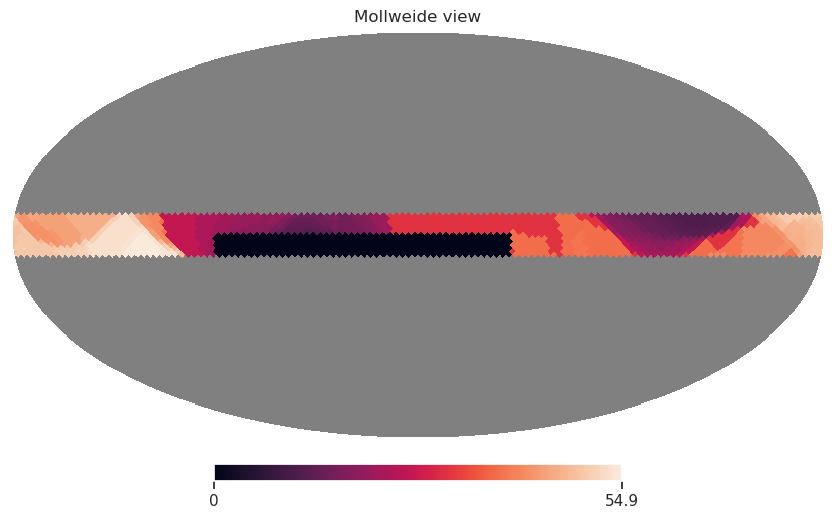

In [66]:
hp.mollview(OWFOM/time,flip='geo',norm='hist')

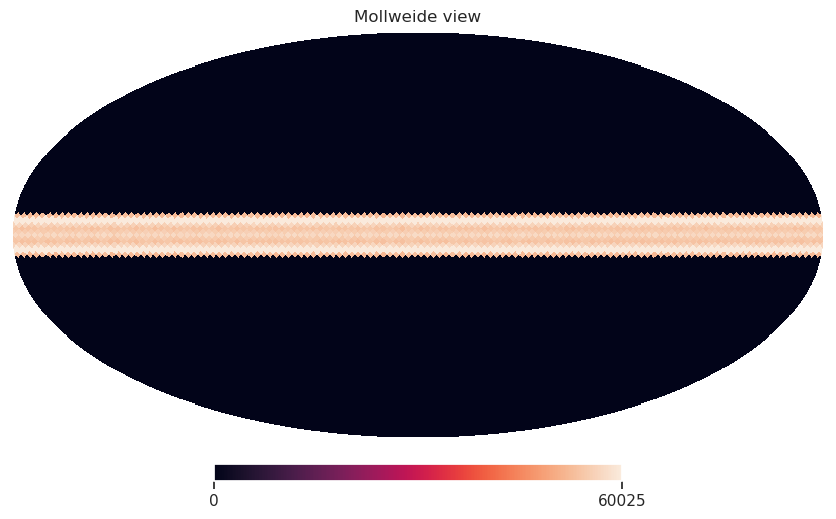

In [67]:
hp.mollview(time,flip='geo',norm='hist')

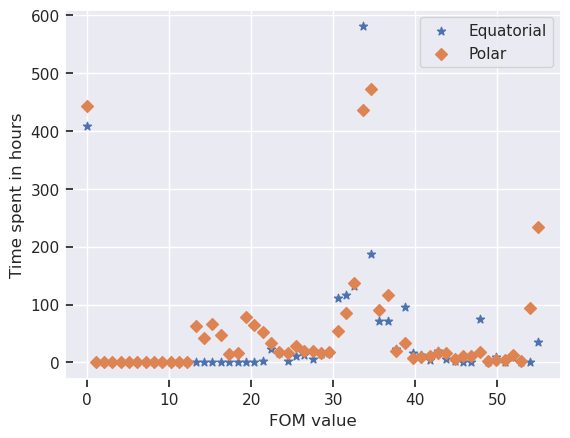

In [113]:
# compare the two orbits:
plt.scatter(fomvals,FOMtime/3600,label='Equatorial',marker='*')
plt.scatter(fomvals,FOMtime1/3600,label='Polar',marker='D')
plt.ylabel('Time spent in hours')
plt.xlabel('FOM value')
# plt.xlim(left=10)
plt.legend()
plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/orbitcomp.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [135]:
FOMtime[-1]/3600

35.05792629665799

## Geosynchronous orbit

### Alt = 36000 km

In [70]:
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[2,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

In [71]:
# open TLE archive
file=open('../TLE_files/NSS.txt')
content=file.read()
ts = load.timescale()
eph=load('de421.bsp')

In [72]:
lineone=[]
linetwo=[]
num=2000
year=np.zeros(num)
month=np.zeros(num)
days=np.zeros((num))
hour=np.zeros((num))
minute=np.zeros((num))
second=np.zeros((num))
for i in range(2000):
    line11=(content[((2*i)*70):((2*i)*70)+69])
    line22=(content[((2*i+1)*70):((2*i+1)*70)+69])
    sate=EarthSatellite(line11,line22,'Landsat7',ts)
#     print(sate)
    lineone.append(line11)
    linetwo.append(line22)
    year=sate.epoch.utc.year
    month=sate.epoch.utc.month
    day=sate.epoch.utc.day
    days[i]+=day
    if year==1999.0:
        if month==11.0:
            if day==20.0:
                   break
    
    
    

In [73]:
uniq_idx=[]
for i in range(len(lineone)):
    if i>0:
        if days[i]!=days[i-1]:
            uniq_idx.append(i)
        
   

In [74]:
subpoints=[]
sunlit=[]
t11=[]
for idx,i in enumerate(uniq_idx):
    if idx==0:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=satellite.epoch.utc
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))
    else:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=t11[idx-1].utc
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))

    

Landsat-8 catalog #33749 epoch 2010-01-02 09:03:57 UTC
Landsat-8 catalog #33749 epoch 2010-01-03 12:49:30 UTC
Landsat-8 catalog #33749 epoch 2010-01-06 15:39:15 UTC
Landsat-8 catalog #33749 epoch 2010-01-07 05:58:44 UTC
Landsat-8 catalog #33749 epoch 2010-01-09 12:42:53 UTC
Landsat-8 catalog #33749 epoch 2010-01-10 13:55:12 UTC
Landsat-8 catalog #33749 epoch 2010-01-11 08:52:19 UTC
Landsat-8 catalog #33749 epoch 2010-01-12 11:37:08 UTC
Landsat-8 catalog #33749 epoch 2010-01-13 11:16:05 UTC
Landsat-8 catalog #33749 epoch 2010-01-14 08:06:20 UTC
Landsat-8 catalog #33749 epoch 2010-01-17 06:34:18 UTC
Landsat-8 catalog #33749 epoch 2010-01-20 15:27:31 UTC
Landsat-8 catalog #33749 epoch 2010-01-24 15:54:35 UTC
Landsat-8 catalog #33749 epoch 2010-01-25 15:51:18 UTC
Landsat-8 catalog #33749 epoch 2010-01-26 11:31:41 UTC
Landsat-8 catalog #33749 epoch 2010-01-27 11:19:46 UTC
Landsat-8 catalog #33749 epoch 2010-01-29 16:10:51 UTC
Landsat-8 catalog #33749 epoch 2010-02-01 05:22:00 UTC
Landsat-8 

Landsat-8 catalog #33749 epoch 2010-09-26 12:19:56 UTC
Landsat-8 catalog #33749 epoch 2010-09-27 09:17:32 UTC
Landsat-8 catalog #33749 epoch 2010-09-28 07:09:49 UTC
Landsat-8 catalog #33749 epoch 2010-09-29 12:50:47 UTC
Landsat-8 catalog #33749 epoch 2010-09-30 12:39:28 UTC
Landsat-8 catalog #33749 epoch 2010-10-03 12:24:01 UTC
Landsat-8 catalog #33749 epoch 2010-10-08 13:23:25 UTC
Landsat-8 catalog #33749 epoch 2010-10-09 05:42:15 UTC
Landsat-8 catalog #33749 epoch 2010-10-11 02:21:07 UTC
Landsat-8 catalog #33749 epoch 2010-10-12 13:04:10 UTC
Landsat-8 catalog #33749 epoch 2010-10-13 13:12:53 UTC
Landsat-8 catalog #33749 epoch 2010-10-15 13:23:35 UTC
Landsat-8 catalog #33749 epoch 2010-10-20 12:35:32 UTC
Landsat-8 catalog #33749 epoch 2010-10-21 12:51:38 UTC
Landsat-8 catalog #33749 epoch 2010-10-23 04:47:50 UTC
Landsat-8 catalog #33749 epoch 2010-10-27 00:00:00 UTC
Landsat-8 catalog #33749 epoch 2010-10-29 15:49:36 UTC
Landsat-8 catalog #33749 epoch 2010-10-30 00:00:00 UTC
Landsat-8 

In [75]:
year_lon=[]
year_lat=[]
for i in range(len(subpoints)):
    year_lon.append(subpoints[i].longitude.degrees)
    year_lat.append(subpoints[i].latitude.degrees)

In [76]:
sunlit=np.array(sunlit)
year_lon=np.array(year_lon)
year_lat=np.array(year_lat)

In [77]:
year_lon=year_lon[:201,:]
year_lat=year_lat[:201,:]

In [78]:
FOMtime1=np.zeros(55)
for i in range(len(year_lat)):
    for j in range(len(year_lat[0])):
        orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
        fomval=int(FOM_map[orbpix])
        if sunlit[i,j]==True:
            FOMtime1[fomval]+=0
        else:
            FOMtime1[fomval]+=deltaT

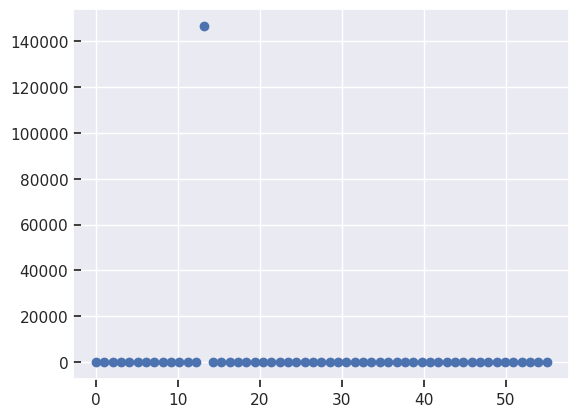

In [79]:
plt.scatter(fomvals,FOMtime1)
plt.show()

In [80]:
FOMtime1[-1]/3600

0.0

In [81]:
OWFOM=np.zeros(hp.nside2npix(nside))
time=np.zeros(np.shape(OWFOM))
for i in year_lat:
    for j in year_lon:
        pix=hp.ang2pix(nside,j,i,lonlat=True)
        OWFOM[pix]+=FOM_map[pix]
        time[pix]+=1
        

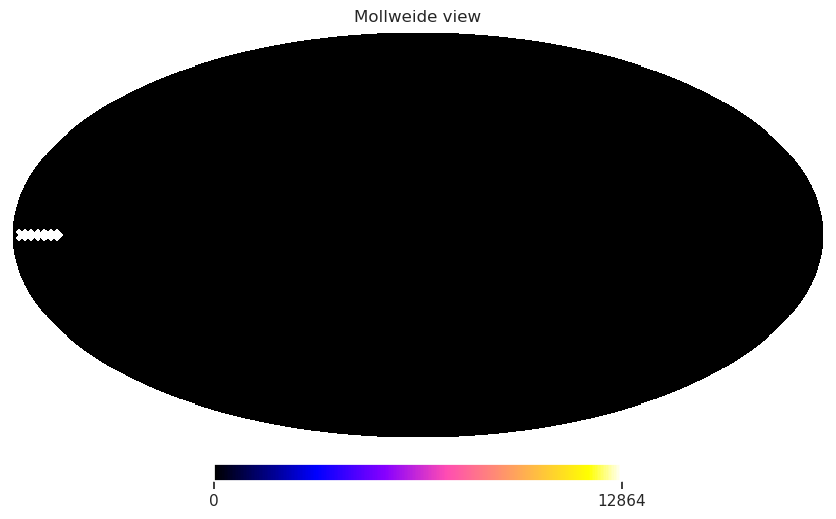

In [82]:
hp.mollview(time,flip='geo',norm='hist',cmap='gnuplot2')
plt.show()

## one day slice 

In [83]:
point=[]
for i in range(len(year_lat)): # i is one day
    foms=[]
    for j in range(len(year_lat[0])): # j is a point in a day of OP
        if sunlit[i,j]==False:
            orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
            fomval=int(FOM_map[orbpix])
            foms.append(fomval) # record FOM at each point of OP for one day
            count=0 # set count to 0
            valz=[] # list to which uninterrupted 54 FOM times will be appended.
            for k in range(len(foms)): # loop through each fom val per day (10000 vals)
                if foms[k]>=thresholdFOM:
                    count+=1 # count gets +1 if FOM is 54.
                else:
                    valz.append(count*(deltaT/60)) # if FOM changes, it appends uninterrupted time and resets count
                    count=0                        # to 0.
    print(f'There is a maximum of {max(valz)} minutes of uninterrupted 55FOM on this day {sum(valz)}') # print max uninterrupted time.

There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a

There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 55FOM on this day 0.0
There is a maximum of 0.0 minutes of uninterrupted 

## RFI temp heatmap

In [84]:
freq_range[144]

90.13599999999997

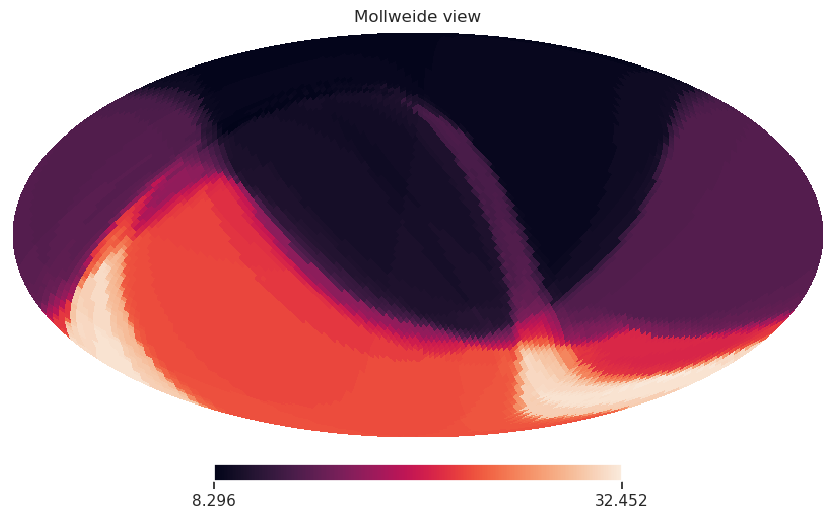

In [85]:
hp.mollview(FOM_map,flip='geo')

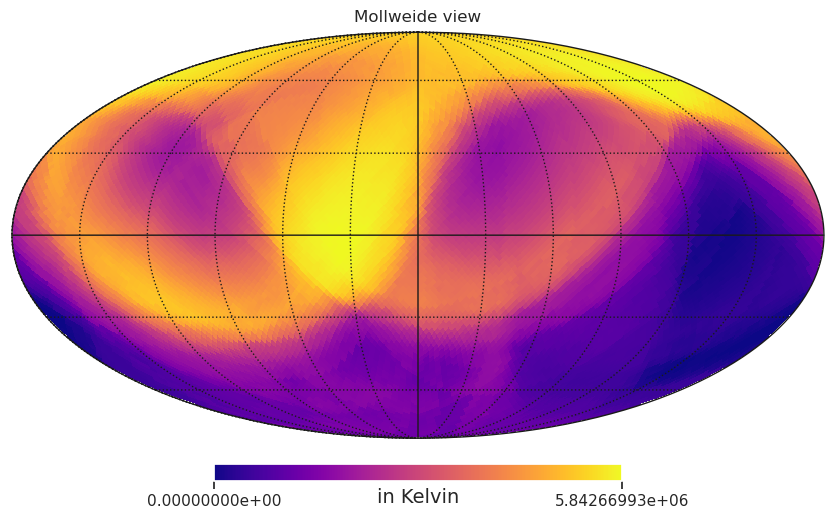

In [86]:
test_plot1 = np.zeros(hp.nside2npix(nside)) 
test_plot1[0:np.size(power_output[1,:,150])] = power_output[2,:,144]
hp.mollview(test_plot1,cmap='plasma',unit="in Kelvin",norm='hist',flip='geo',format= '%.8e',min=0)#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/RFI_latestHM.pdf')
plt.show()

In [87]:
powercube_df=pd.DataFrame(power_output[1,:,:])
powercube_df.to_csv('/home/saurabhs/Documents/Yogen_starfire/Synth705.csv')